In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
import pandas as pd
from PyAstronomy import pyasl
from scipy.signal import medfilt
from scipy.ndimage import gaussian_filter1d
from photutils.detection import DAOStarFinder
from astropy.stats import mad_std
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.visualization.wcsaxes import SphericalCircle
from astroquery.vizier import Vizier
import matplotlib.patches as patches
from scipy.signal import savgol_filter
from matplotlib.lines import Line2D


In [2]:
#OB16170
#archivo_weave_oficial = "weave_L1/stackcube_3105092.fit"

#OB16169
#archivo_weave_oficial = "weave_L1/stackcube_3117894.fit"

#OB16168
#archivo_weave_oficial = "weave_L1/stackcube_3117842.fit"

#OB16167
#archivo_weave_oficial = "weave_L1/stackcube_3121264.fit"

#OB16166
archivo_weave_oficial = "weave_L1/stackcube_3121049.fit"

In [3]:

hdul = fits.open("mis_cubos/mi_cubo_OB16166.fits")

cube = hdul['FLUX'].data
header = hdul['FLUX'].header.copy()
#header = hdul['FLUX'].header
header['CDELT1'] = header['CDELT1'] * -1
wcs = WCS(header).celestial 

# =============================================================================
# 2. RECUPERAR COORDENADAS ESPACIALES 
# =============================================================================

pixscale_arcsec = header['CDELT2'] * 3600.0  

ra0 = header['CRVAL1']   
dec0 = header['CRVAL2']  

# Reconstruimos xmin e ymin despejando las fórmulas originales:
# CRPIX1 = -xmin / pixscale_arcsec + 1
xmin = -(header['CRPIX1'] - 1) * pixscale_arcsec
ymin = -(header['CRPIX2'] - 1) * pixscale_arcsec

# Calculamos los bordes máximos en función del tamaño real de la matriz
ny, nx = cube.shape[1], cube.shape[2]
xmax = xmin + (nx * pixscale_arcsec)
ymax = ymin + (ny * pixscale_arcsec)

# =============================================================================
# 3. RECUPERAR EL EJE ESPECTRAL 
# =============================================================================
nw = cube.shape[0]
w_start = header['CRVAL3']  
w_step = header['CDELT3']   

wave_ref = w_start + np.arange(nw) * w_step

print("Cubo cargado")
print(f"Centro: RA={ra0:.4f}, Dec={dec0:.4f}")
print(f"Escala: {pixscale_arcsec:.2f} arcsec/pix")

Cubo cargado
Centro: RA=24.0820, Dec=64.5363
Escala: 0.60 arcsec/pix


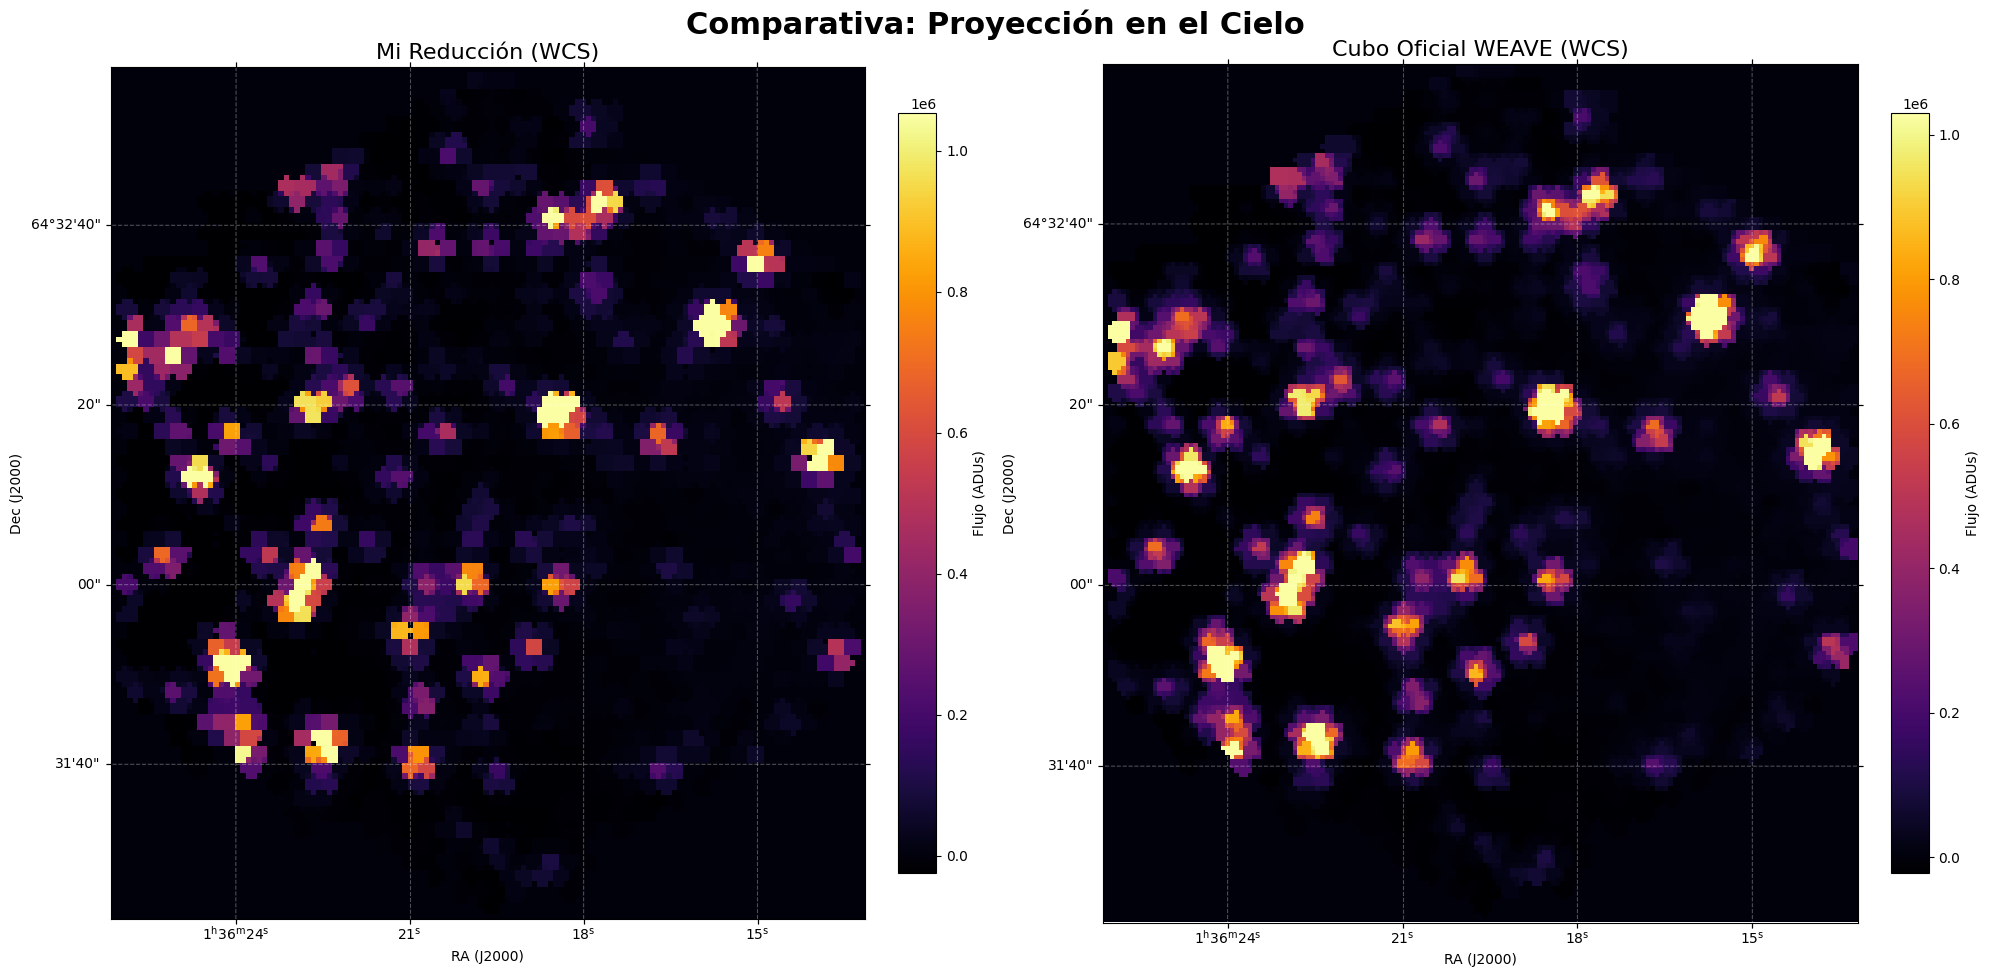

In [4]:

# --- CARGAR CUBO OFICIAL Y SU WCS ---
ruta_oficial = os.path.expanduser(archivo_weave_oficial)

if os.path.exists(ruta_oficial):
    with fits.open(ruta_oficial) as hdul:
        datos_oficial = hdul[1].data
        header_oficial = hdul[1].header
        wcs_oficial = WCS(header_oficial).celestial
        imagen_oficial = np.nansum(datos_oficial, axis=0)
else:
    print(f"Error: No se encontró {ruta_oficial}")
    imagen_oficial = np.zeros((100, 100))
    wcs_oficial = wcs 

# --- IMAGEN BLANCA PROPIA ---
imagen_mi_cubo = np.nansum(cube, axis=0)

fig = plt.figure(figsize=(20, 10))

ax1 = fig.add_subplot(1, 2, 1, projection=wcs)
vmin1, vmax1 = np.nanpercentile(imagen_mi_cubo, [5, 99])

im1 = ax1.imshow(imagen_mi_cubo, origin='lower', cmap='inferno', vmin=vmin1, vmax=vmax1)
ax1.set_title("Mi Reducción (WCS)", fontsize=16)

ax1.coords['ra'].set_axislabel('RA (J2000)')
ax1.coords['dec'].set_axislabel('Dec (J2000)')
ax1.coords['ra'].set_major_formatter('hh:mm:ss')
ax1.coords['dec'].set_major_formatter('dd:mm:ss')

plt.colorbar(im1, ax=ax1, label="Flujo (ADUs)", fraction=0.046, pad=0.04)
ax1.grid(color='white', alpha=0.3, linestyle='--')

ax2 = fig.add_subplot(1, 2, 2, projection=wcs_oficial)
vmin2, vmax2 = np.nanpercentile(imagen_oficial, [5, 99])

im2 = ax2.imshow(imagen_oficial, origin='lower', cmap='inferno', vmin=vmin2, vmax=vmax2)
ax2.set_title("Cubo Oficial WEAVE (WCS)", fontsize=16)

ax2.coords['ra'].set_axislabel('RA (J2000)')
ax2.coords['dec'].set_axislabel('Dec (J2000)')
ax2.coords['ra'].set_major_formatter('hh:mm:ss')
ax2.coords['dec'].set_major_formatter('dd:mm:ss')

plt.colorbar(im2, ax=ax2, label="Flujo (ADUs)", fraction=0.046, pad=0.04)
ax2.grid(color='white', alpha=0.3, linestyle='--')

ax1.invert_xaxis() # Descomentar si la RA de "Mi Reducción" crece a la derecha
#ax2.invert_xaxis() # Descomentar si la RA del "Cubo Oficial" crece a la derecha

plt.suptitle("Comparativa: Proyección en el Cielo", fontsize=22, fontweight='bold')
plt.tight_layout()
plt.show()

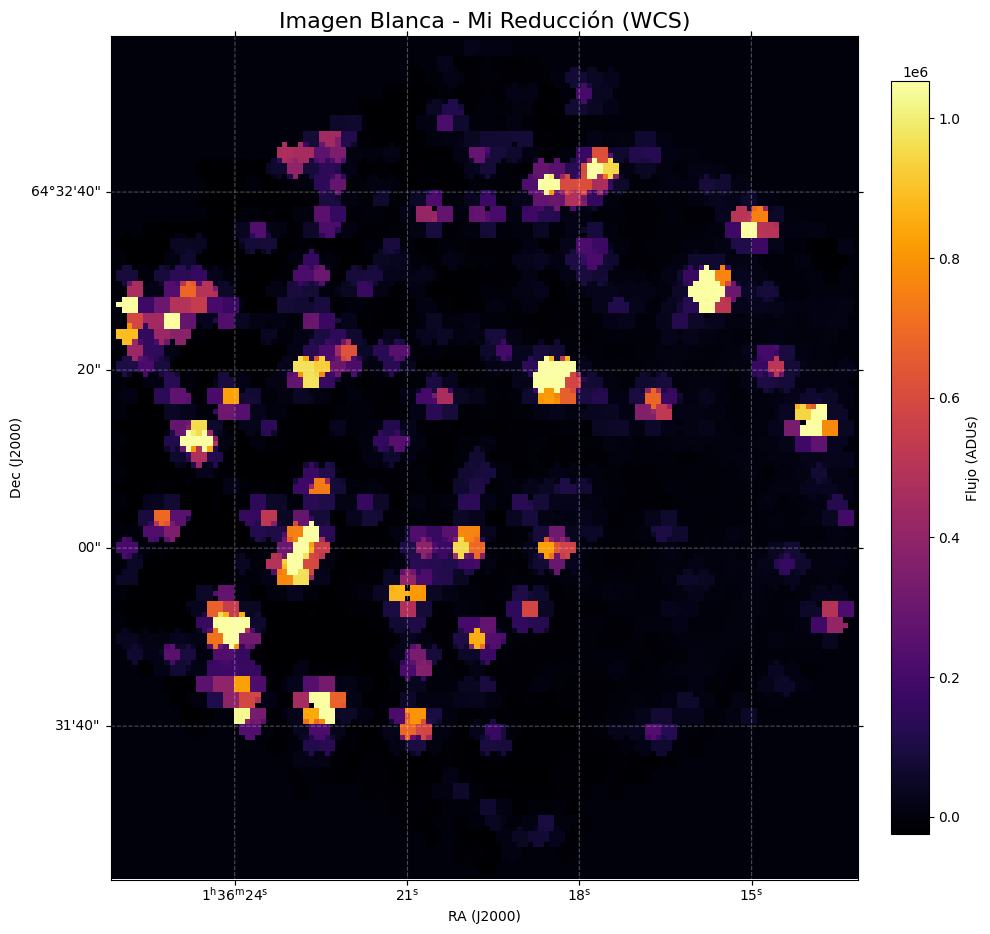

In [5]:

# =========================================================
# CREAR LA "WHITE IMAGE" 
# =========================================================

white = imagen_mi_cubo
vmin1, vmax1 = np.nanpercentile(white, [5, 99])

plt.figure(figsize=(10, 10))
ax = plt.subplot(1, 1, 1, projection=wcs) 

im = ax.imshow(white, origin='lower', cmap='inferno', vmin=vmin1, vmax=vmax1)
ax.set_title("Imagen Blanca - Mi Reducción (WCS)", fontsize=16)

ax.coords['ra'].set_axislabel('RA (J2000)')
ax.coords['dec'].set_axislabel('Dec (J2000)')
ax.coords['ra'].set_major_formatter('hh:mm:ss')
ax.coords['dec'].set_major_formatter('dd:mm:ss')

plt.colorbar(im, ax=ax, label="Flujo (ADUs)", fraction=0.046, pad=0.04)
ax.grid(color='white', alpha=0.3, linestyle='--')

ax.invert_xaxis()
plt.tight_layout()
plt.show()

RANGO ESPECTRAL DISPONIBLE EN ESTE CUBO:
Mínimo: 3600.00 Å
Máximo: 5950.00 Å
Resolución: 0.50 Å/píxel
Haciendo corte espectral centrado en 5007 Å (Rango: 5001 - 5013 Å)...


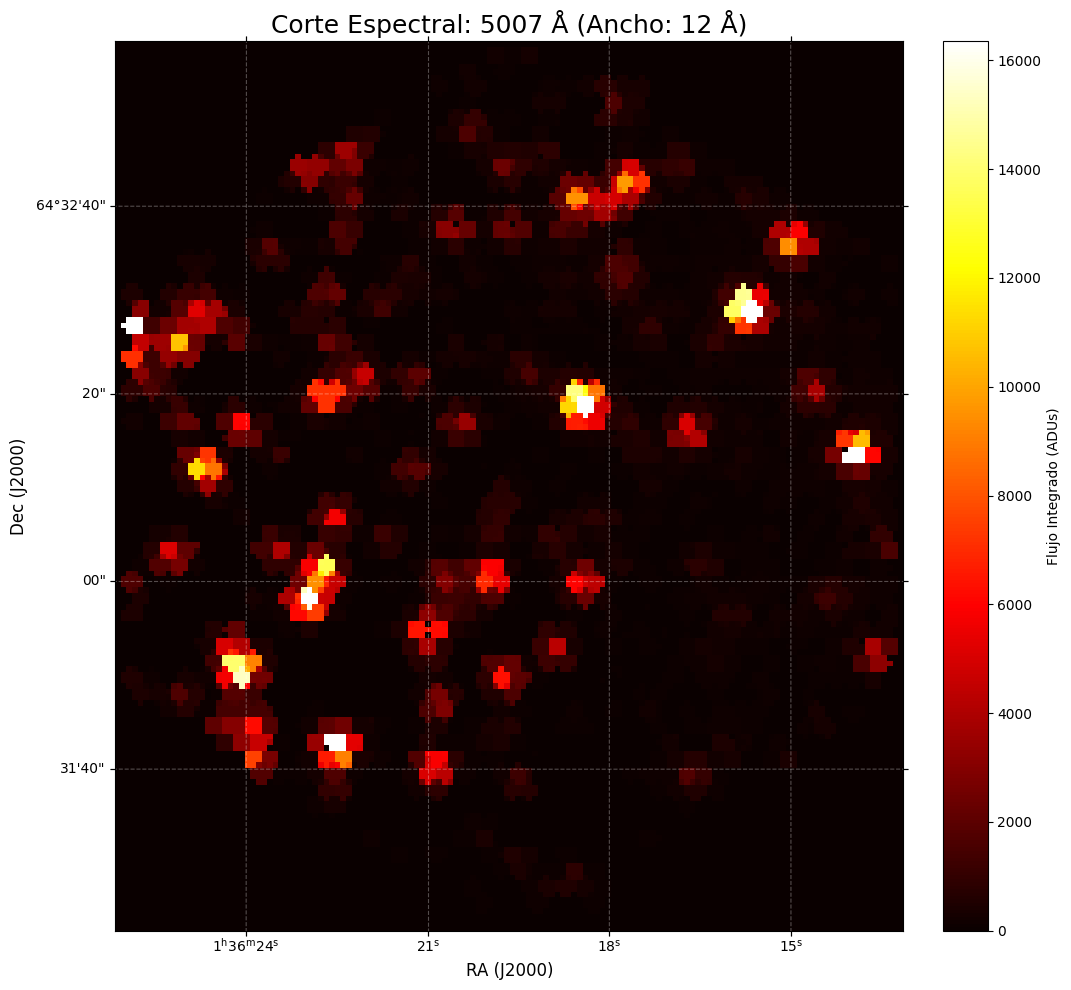

In [6]:
# =============================================================================
# CORTE ESPECTRAL (IMAGEN DE BANDA ESTRECHA)
# =============================================================================

w_min = wave_ref.min()
w_max = wave_ref.max()
w_res = wave_ref[1] - wave_ref[0]

print(f"RANGO ESPECTRAL DISPONIBLE EN ESTE CUBO:")
print(f"Mínimo: {w_min:.2f} Å")
print(f"Máximo: {w_max:.2f} Å")
print(f"Resolución: {w_res:.2f} Å/píxel")

# Elige la longitud de onda y el ancho 
lambda_central = 5007 
ancho_corte = 6 

lamin = lambda_central - ancho_corte
lamax = lambda_central + ancho_corte

print(f"Haciendo corte espectral centrado en {lambda_central} Å (Rango: {lamin} - {lamax} Å)...")


mask_corte = (wave_ref >= lamin) & (wave_ref <= lamax)

# Si el corte cae fuera de nuestro cubo, avisamos
if not np.any(mask_corte):
    print("Esa longitud de onda no está dentro del rango del cubo.")
else:
    # Aplastamos solo esas capas del cubo 3D
    mapa_corte = np.nansum(cube[mask_corte, :, :], axis=0)

    # Limpiamos el ruido físico
    mapa_corte[mapa_corte < 0] = 0 

    # =============================================================================
    # GRÁFICA DEL CORTE
    # =============================================================================
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(1, 1, 1, projection=wcs)

    # Calculamos el máximo real de esta capa concreta para que brille bien
    pixeles_validos = mapa_corte[mapa_corte > 0]
    if len(pixeles_validos) > 0:
        vmax_corte = np.nanpercentile(pixeles_validos, 99.5)
    else:
        vmax_corte = 1 # Por si justo cortas en una zona totalmente negra

    im = ax.imshow(mapa_corte, origin='lower', cmap='hot', vmin=0, vmax=vmax_corte)

    ax.set_title(f"Corte Espectral: {lambda_central} Å (Ancho: {ancho_corte*2} Å)", fontsize=18)
    
    ax.coords['ra'].set_axislabel('RA (J2000)', fontsize=12)
    ax.coords['dec'].set_axislabel('Dec (J2000)', fontsize=12)
    ax.coords['ra'].set_major_formatter('hh:mm:ss')
    ax.coords['dec'].set_major_formatter('dd:mm:ss')

    plt.colorbar(im, ax=ax, label="Flujo Integrado (ADUs)", fraction=0.046, pad=0.04)
    ax.grid(color='white', alpha=0.3, linestyle='--')
    ax.invert_xaxis()

    plt.tight_layout()
    plt.show()


Se han encontrado 74 estrellas reales en la zona central segura (r < 40.0")

--- LISTA DE ESTRELLAS DETECTADAS ---
 id         ra                dec            mag        peak  
--- ------------------ ----------------- ----------- ---------
  3 24.083845297593808 64.52572137322638  -13.953399 56310.285
  4 24.081241436916446 64.52746469599668  -16.151512 170987.78
  5  24.06937924228356 64.52761272296499  -16.818214 237147.02
  6  24.08698691140729 64.52787092802981  -18.388283  797087.7
  8 24.099356568434267 64.52827356863547  -18.455902 1027698.1
  9 24.067401306346497  64.5283966146635   -15.60802 56788.277
 10  24.09376397291753 64.52851952027453  -19.469692 2663699.0
 11 24.082165660233255 64.52898396398561 -15.4178915  91694.72
 13 24.086708401788098 64.52974070872027  -17.458588  345108.3
 16  24.08233109638518 64.53051490269492  -18.066717  856600.5
 17 24.100481070801127 64.53080036652631   -19.54563 1879232.9
 19 24.078677670883973 64.53138588198206  -17.612865  582283.4
 2

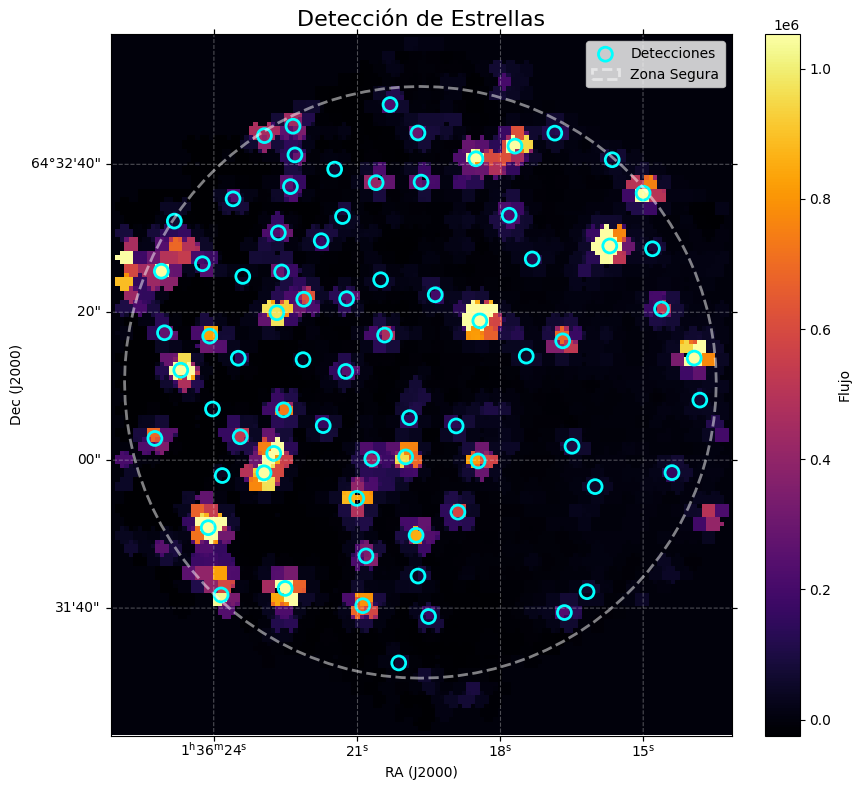

In [7]:
# =============================================================================
# BUSCADOR (DAOStarFinder)
# =============================================================================
data_find = white.copy()
data_find[np.isnan(data_find)] = 0  

# Estimamos el ruido de fondo (sigma)
bkg_sigma = mad_std(data_find[data_find > 0])
umbral_deteccion = 1.5 * bkg_sigma

daofind = DAOStarFinder(fwhm=6.5, threshold=umbral_deteccion)  
sources = daofind(data_find)

if sources is None:
    print("No se ha detectado ninguna estrella con este umbral.")
else:
    # Pasamos de píxeles a grados reales usando el WCS del cubo
    ra_fin, dec_fin = wcs.pixel_to_world_values(sources['xcentroid'], sources['ycentroid'])
    
    sources['ra'] = ra_fin
    sources['dec'] = dec_fin
    
    c_centro = SkyCoord(ra=ra0*u.deg, dec=dec0*u.deg)
    c_detecciones = SkyCoord(ra=ra_fin*u.deg, dec=dec_fin*u.deg)
    
    distancias = c_centro.separation(c_detecciones).arcsec
    
    # Ignoramos los bordes ruidosos
    radio_restringido_arcsec = 40.0 
    mask_segura = distancias < radio_restringido_arcsec
    sources = sources[mask_segura]

    print(f"\nSe han encontrado {len(sources)} estrellas reales en la zona central segura (r < {radio_restringido_arcsec}\")")

    print("\n--- LISTA DE ESTRELLAS DETECTADAS ---")
    sources['id', 'ra', 'dec', 'mag', 'peak'].pprint_all()
    
    # =============================================================================
    #  VISUALIZACIÓN 
    # =============================================================================
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(1, 1, 1, projection=wcs)
    
    # Calculamos el contraste óptimo
    good_white = np.isfinite(white)
    vmin_plot, vmax_plot = np.nanpercentile(white[good_white], [5, 99])
    
    # Dibujamos la imagen de fondo
    im = ax.imshow(white, origin='lower', cmap='inferno', vmin=vmin_plot, vmax=vmax_plot)
    ax.set_title("Detección de Estrellas", fontsize=16)
    
    ax.coords['ra'].set_axislabel('RA (J2000)')
    ax.coords['dec'].set_axislabel('Dec (J2000)')
    ax.coords['ra'].set_major_formatter('hh:mm:ss')
    ax.coords['dec'].set_major_formatter('dd:mm:ss')
    
    # Dibujamos las estrellas usando transform para que entienda que son grados
    ax.scatter(sources['ra'], sources['dec'], transform=ax.get_transform('world'), 
               s=100, edgecolor='cyan', facecolor='none', lw=2, label='Detecciones')
    
    circulo_seguridad = SphericalCircle((ra0 * u.deg, dec0 * u.deg), radio_restringido_arcsec * u.arcsec,
                                        edgecolor='white', facecolor='none', ls='--', lw=2, alpha=0.5,
                                        transform=ax.get_transform('world'), label=f'Zona Segura')
    ax.add_patch(circulo_seguridad)
    
    ax.invert_xaxis()
    plt.colorbar(im, ax=ax, label="Flujo", fraction=0.046, pad=0.04)
    ax.grid(color='white', alpha=0.3, linestyle='--')
    ax.legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

 57 estrellas validadas con Gaia DR3.


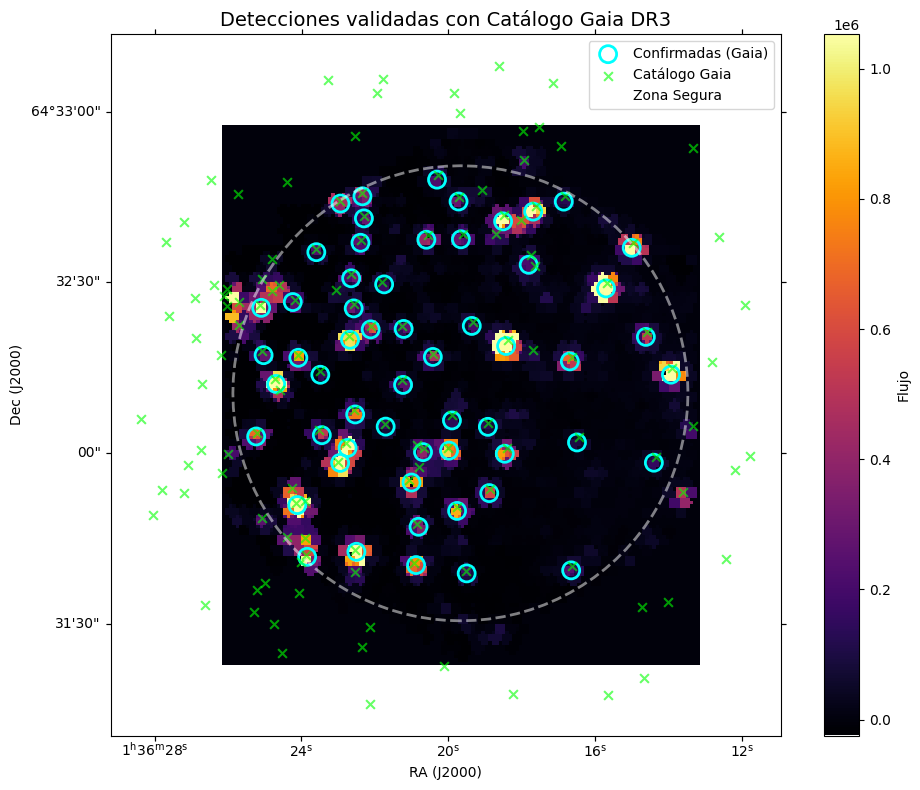

In [8]:
# =============================================================================
# CONSULTA GAIA DR3 
# =============================================================================

v = Vizier(row_limit=-1, columns=['RA_ICRS', 'DE_ICRS', 'Gmag', 'BPmag', 'RPmag', 'pmRA', 'pmDE', 'Plx']) 
#v.VIZIER_SERVER = 'vizier.cfa.harvard.edu' 
v.VIZIER_SERVER = 'vizier.cds.unistra.fr'

centro_campo = SkyCoord(ra=ra0*u.deg, dec=dec0*u.deg, frame='icrs')
result = v.query_region(centro_campo, radius=60*u.arcsec, catalog='I/355/gaiadr3')
hay_gaia = False 

if result is None or len(result) == 0:
    print("No hay fuentes Gaia en esta región.")
    sources_final = sources
else:
    table_gaia = result[0]
    mask_brillantes = table_gaia['Gmag'] < 18.5 
    table_gaia = table_gaia[mask_brillantes]
    
    if len(table_gaia) == 0:
        print("No hay estrellas Gaia lo suficientemente brillantes.")
        sources_final = sources
    else:
        hay_gaia = True 
        coords_mias = SkyCoord(ra=sources['ra']*u.deg, dec=sources['dec']*u.deg)
        coords_gaia = SkyCoord(ra=table_gaia['RA_ICRS'], dec=table_gaia['DE_ICRS'])
        
        idx, d2d, _ = coords_mias.match_to_catalog_sky(coords_gaia)
        tolerancia = 1.5 * u.arcsec
        matches = d2d < tolerancia
        
        sources_final = sources[matches]
        sources_final['Gmag'] = table_gaia['Gmag'][idx[matches]]
        sources_final['pmra'] = table_gaia['pmRA'][idx[matches]]
        sources_final['pmdec'] = table_gaia['pmDE'][idx[matches]]
        sources_final['parallax'] = table_gaia['Plx'][idx[matches]]
        sources_final['dist_arcsec'] = d2d[matches].to(u.arcsec)

        for col in ['BPmag', 'RPmag']:
            if col in table_gaia.colnames:
                sources_final[col] = table_gaia[col][idx[matches]]

        print(f" {len(sources_final)} estrellas validadas con Gaia DR3.")


fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection=wcs)

good_white = np.isfinite(white)
vmin_plot, vmax_plot = np.nanpercentile(white[good_white], [5, 99])

im = ax.imshow(white, origin='lower', cmap='inferno', vmin=vmin_plot, vmax=vmax_plot)

ax.scatter(sources_final['ra'], sources_final['dec'], transform=ax.get_transform('world'), 
           s=150, edgecolor='cyan', facecolor='none', lw=2, label='Confirmadas (Gaia)')

if hay_gaia:
    ax.scatter(table_gaia['RA_ICRS'], table_gaia['DE_ICRS'], transform=ax.get_transform('world'), 
               marker='x', s=40, color='lime', alpha=0.6, label='Catálogo Gaia')
               
circulo_seguridad = SphericalCircle((ra0 * u.deg, dec0 * u.deg), radio_restringido_arcsec * u.arcsec,
                                    edgecolor='white', facecolor='none', ls='--', lw=2, alpha=0.5,
                                    transform=ax.get_transform('world'), label=f'Zona Segura')
ax.add_patch(circulo_seguridad)

ax.coords['ra'].set_axislabel('RA (J2000)')
ax.coords['dec'].set_axislabel('Dec (J2000)')
ax.coords['ra'].set_major_formatter('hh:mm:ss')
ax.coords['dec'].set_major_formatter('dd:mm:ss')
ax.invert_xaxis()

coord1 = SkyCoord(ra="1h36m35.5s", dec="64d32m20s", frame="icrs")
coord2 = SkyCoord(ra="1h36m22.5s", dec="64d33m50s", frame="icrs")

x1, y1 = wcs.world_to_pixel(coord1)
x2, y2 = wcs.world_to_pixel(coord2)

plt.colorbar(im, ax=ax, label="Flujo")
plt.title("Detecciones validadas con Catálogo Gaia DR3", fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

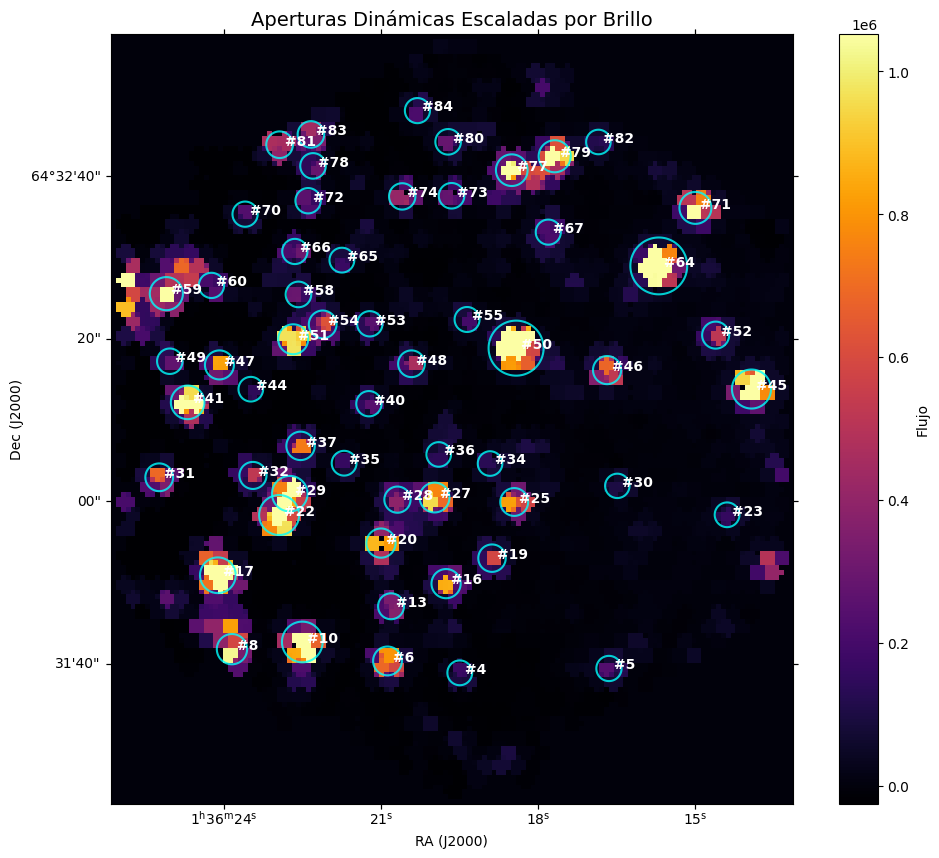

In [9]:

# RECONSTRUIR LA REJILLA ESPACIAL 
ny, nx = cube.shape[1], cube.shape[2]
x_centers = xmin + (np.arange(nx) + 0.5) * pixscale_arcsec
y_centers = ymin + (np.arange(ny) + 0.5) * pixscale_arcsec
XX, YY = np.meshgrid(x_centers, y_centers)

def extraer_espectro_apertura_fast(cube, XX, YY, ra0, dec0, ra_obj, dec_obj, radio_arcsec):
    estrella_x = (ra_obj - ra0) * np.cos(np.deg2rad(dec0)) * 3600.0
    estrella_y = (dec_obj - dec0) * 3600.0
    
    # Máscara circular
    distancia_al_centro = np.sqrt((XX - estrella_x)**2 + (YY - estrella_y)**2)
    mascara_apertura = distancia_al_centro <= radio_arcsec
    
    # Extraer sumando las fibras/píxeles dentro de la máscara
    espectro = np.nansum(cube[:, mascara_apertura], axis=1)
    return espectro

# =========================================================
#  BUCLE DE EXTRACCIÓN CON RADIO DINÁMICO
# =========================================================
espectros_extraidos = {} 
radios_usados = []

flujo_min = np.min(sources_final['peak'])
flujo_max = np.max(sources_final['peak'])
radio_minimo, radio_maximo = 1.5, 3.5

for row in sources_final:
    # Cálculo del radio dinámico
    if flujo_max == flujo_min:
        radio_dinamico = radio_maximo
    else:
        proporcion = (row['peak'] - flujo_min) / (flujo_max - flujo_min)
        radio_dinamico = radio_minimo + (radio_maximo - radio_minimo) * proporcion
    
    radios_usados.append(radio_dinamico)

    espectro = extraer_espectro_apertura_fast(
        cube, XX, YY, ra0, dec0, row['ra'], row['dec'], radio_dinamico
    )
    
    espectros_extraidos[row['id']] = espectro

sources_final['radio_ext'] = radios_usados 

# =========================================================
#  VISUALIZACIÓN CON WCS 
# =========================================================
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(1, 1, 1, projection=wcs)

im = ax.imshow(white, origin="lower", cmap="inferno", vmin=vmin_plot, vmax=vmax_plot)

for row in sources_final:
    # radio_ext está en arcsec, lo pasamos a grados para la función
    circ = SphericalCircle(
        (row['ra'] * u.deg, row['dec'] * u.deg), 
        row['radio_ext'] * u.arcsec,
        edgecolor='cyan', facecolor='none', lw=1.5, alpha=0.8,
        transform=ax.get_transform('world')
    )
    ax.add_patch(circ)
    
    ax.text(row['ra'], row['dec'], f" #{row['id']}", color='white', 
            fontsize=10, fontweight='bold', transform=ax.get_transform('world'))

ax.coords['ra'].set_axislabel('RA (J2000)')
ax.coords['dec'].set_axislabel('Dec (J2000)')
ax.invert_xaxis()

plt.colorbar(im, ax=ax, label="Flujo")
plt.title("Aperturas Dinámicas Escaladas por Brillo", fontsize=14)
plt.show()

 Se han guardado 57 espectros.


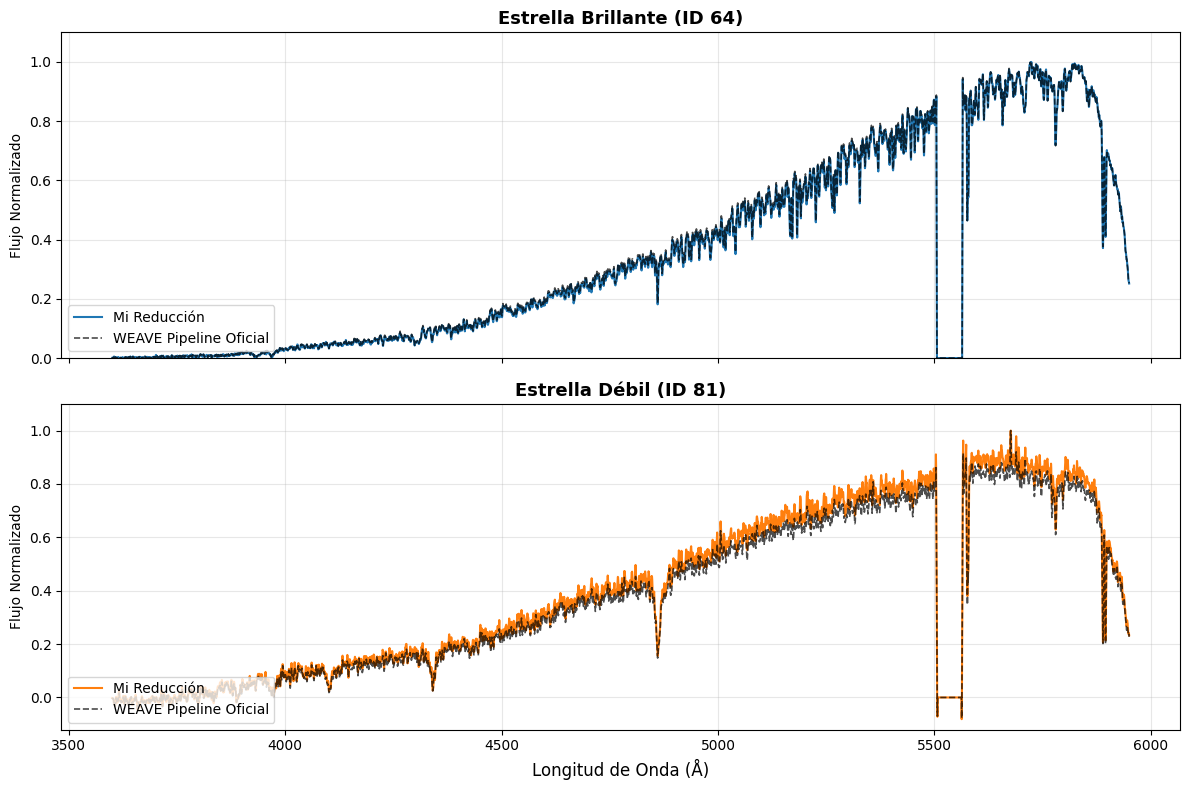

In [10]:
# =========================================================
#  FUNCIONES PRINCIPALES
# =========================================================
def extraer_espectro_oficial(archivo_fits, ra_obj, dec_obj, radio_arcsec):
    with fits.open(archivo_fits) as hdul:
        cube_oficial = hdul[1].data 
        header_oficial = hdul[1].header
        
        cdelt_wave = header_oficial.get("CDELT3", header_oficial.get("CD3_3"))
        crval_wave = header_oficial["CRVAL3"]
        crpix_wave = header_oficial["CRPIX3"]
        wave_oficial = crval_wave + (np.arange(header_oficial["NAXIS3"]) + 1 - crpix_wave) * cdelt_wave
        
        wcs_celeste = WCS(header_oficial).celestial
        x_pix, y_pix = wcs_celeste.world_to_pixel_values(ra_obj, dec_obj)
        
        pixscale_deg = np.abs(header_oficial.get("CDELT2", header_oficial.get("CD2_2")))
        radio_pix = radio_arcsec / (pixscale_deg * 3600.0)
        
        ny, nx = cube_oficial.shape[1], cube_oficial.shape[2]
        Y, X = np.indices((ny, nx))
        dist = np.sqrt((X - x_pix)**2 + (Y - y_pix)**2)
        mascara = dist <= radio_pix
        
        espectro_of = np.nansum(cube_oficial[:, mascara], axis=1)
        return wave_oficial, espectro_of

def suavizado_inteligente(wave, espectro):
    """Aplica un filtro Savitzky-Golay cuyo tamaño depende del SNR local"""
    mask_snr = (wave > 5000) & (wave < 5100)
    chunk = espectro[mask_snr]
    
    senal = np.nanmedian(chunk)
    ruido = np.nanstd(chunk - gaussian_filter1d(chunk, 2))
    
    if ruido <= 0 or np.isnan(ruido): snr = 0.1
    else: snr = senal / ruido

    if snr > 25: ventana = 5
    elif snr > 15: ventana = 9
    elif snr > 8: ventana = 15
    else: ventana = 25 
        
    if ventana % 2 == 0: ventana += 1

    espectro_suavizado = savgol_filter(espectro, window_length=ventana, polyorder=3)
    return espectro_suavizado, snr, ventana


espectros_finales = {}

for row in sources_final:
    s_id = row['id']
    ra_obj = row['ra']
    dec_obj = row['dec']
    
    if s_id not in espectros_extraidos:
        continue
    esp_bruto_mio = espectros_extraidos[s_id]
    
    esp_suav_mio, snr_calc, vent = suavizado_inteligente(wave_ref, esp_bruto_mio)
    
    espectros_finales[s_id] = {
        'wave': wave_ref,
        'flujo_bruto': esp_bruto_mio,
        'flujo_suavizado': esp_suav_mio,
        'snr': snr_calc,
        'ventana_savgol': vent,
        'ra': ra_obj,   
        'dec': dec_obj
    }

print(f" Se han guardado {len(espectros_finales)} espectros.")

# =========================================================
#  SELECCIÓN DE EXTREMOS PARA LA GRÁFICA
# =========================================================
columna_brillo = 'peak' 

# --- ESTRELLA BRILLANTE ---
idx_max = np.argmax(sources_final[columna_brillo])
ID_BRILLANTE = sources_final['id'][idx_max]

# Ordenamos los índices de todas las estrellas de la más débil a la más brillante
indices_ordenados = np.argsort(sources_final[columna_brillo])

indice_ideal = int(len(indices_ordenados) * 0.50)
idx_debil_mejorada = indices_ordenados[indice_ideal]

ID_DEBIL = sources_final['id'][idx_debil_mejorada]

# --- ESTRELLA BRILLANTE ---
mask_brill = sources_final['id'] == ID_BRILLANTE
ra_b, dec_b, rad_b = sources_final[mask_brill]['ra'][0], sources_final[mask_brill]['dec'][0], sources_final[mask_brill]['radio_ext'][0]

wave_of_brill, esp_of_bruto_brill = extraer_espectro_oficial(archivo_weave_oficial, ra_b, dec_b, rad_b)
# Suavizamos el oficial porque lo extraemos crudo
esp_of_suav_brill, _, _ = suavizado_inteligente(wave_of_brill, esp_of_bruto_brill)

# --- ESTRELLA DÉBIL ---
mask_debil = sources_final['id'] == ID_DEBIL
ra_d, dec_d, rad_d = sources_final[mask_debil]['ra'][0], sources_final[mask_debil]['dec'][0], sources_final[mask_debil]['radio_ext'][0]

wave_of_debil, esp_of_bruto_debil = extraer_espectro_oficial(archivo_weave_oficial, ra_d, dec_d, rad_d)
# Suavizamos el oficial
esp_of_suav_debil, _, _ = suavizado_inteligente(wave_of_debil, esp_of_bruto_debil)

# =========================================================
#  NORMALIZACIÓN VISUAL Y GRÁFICA
# =========================================================
# Rescatamos los espectros ya suavizados del diccionario definitivo
mio_suav_brill = espectros_finales[ID_BRILLANTE]['flujo_suavizado']
mio_suav_debil = espectros_finales[ID_DEBIL]['flujo_suavizado']

# Normalizamos todo de 0 a 1 solo para la gráfica
norm_mio_brill = mio_suav_brill / np.nanmax(mio_suav_brill)
norm_of_brill = esp_of_suav_brill / np.nanmax(esp_of_suav_brill)

norm_mio_debil = mio_suav_debil / np.nanmax(mio_suav_debil)
norm_of_debil = esp_of_suav_debil / np.nanmax(esp_of_suav_debil)

# --- DIBUJAMOS LA GRÁFICA ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(espectros_finales[ID_BRILLANTE]['wave'], norm_mio_brill, color='#1f77b4', linewidth=1.5, label="Mi Reducción")
ax1.plot(wave_of_brill, norm_of_brill, color='black', linewidth=1.2, linestyle='--', alpha=0.7, label="WEAVE Pipeline Oficial")
ax1.set_title(f"Estrella Brillante (ID {ID_BRILLANTE})", fontsize=13, fontweight='bold')
ax1.set_ylabel("Flujo Normalizado")
ax1.grid(True, alpha=0.3)
ax1.legend(loc='lower left')
ax1.set_ylim(0, 1.1)

ax2.plot(espectros_finales[ID_DEBIL]['wave'], norm_mio_debil, color='#ff7f0e', linewidth=1.5, label="Mi Reducción")
ax2.plot(wave_of_debil, norm_of_debil, color='black', linewidth=1.2, linestyle='--', alpha=0.7, label="WEAVE Pipeline Oficial")
ax2.set_title(f"Estrella Débil (ID {ID_DEBIL})", fontsize=13, fontweight='bold')
ax2.set_ylabel("Flujo Normalizado")
ax2.set_xlabel("Longitud de Onda (Å)", fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.legend(loc='lower left')
ax2.set_ylim(np.nanpercentile(norm_mio_debil, 1) - 0.1, 1.1)

plt.tight_layout()
plt.show()

In [11]:
# =========================================================
#  FUNCIÓN DE PROCESADO Y PREPARACIÓN DE PLANTILLAS
# =========================================================
def procesar_para_ccf(flux):
    f = np.array(flux, dtype=np.float64)
    if np.isnan(f).any() or np.isinf(f).any():
        f = np.nan_to_num(f, nan=np.nanmedian(f), posinf=np.nanmedian(f), neginf=np.nanmedian(f))
        
    f_suave = medfilt(f, kernel_size=3)
    continuo_suave = gaussian_filter1d(f_suave, 50) 
    f_solo_lineas = f_suave - continuo_suave
    
    std = np.nanstd(f_solo_lineas)
    if std == 0 or np.isnan(std): return f_solo_lineas * 0
    return (f_solo_lineas - np.nanmean(f_solo_lineas)) / std

# =========================================================
#  BUCLE DE CORRELACIÓN
# =========================================================
def calcular_rv(w_obs, f_obs_ready, f_temp_ready, margen=150):
    rv, cc = pyasl.crosscorrRV(
        w_obs[margen:-margen], f_obs_ready[margen:-margen], 
        w_obs, f_temp_ready, 
        rvmin=-150., rvmax=150., drv=0.1, mode='doppler'
    )
    max_idx = np.argmax(cc)
    if 0 < max_idx < len(rv) - 1:
        y_pts = cc[max_idx-1:max_idx+2]
        x_pts = rv[max_idx-1:max_idx+2]
        p = np.polyfit(x_pts, y_pts, 2)
        v_final = -p[1] / (2 * p[0])
    else:
        v_final = rv[max_idx]
    return v_final, cc[max_idx]


# Cargamos y proyectamos las plantillas
datos = np.load('plantillas_maestras_OB16166.npz')    # para baja calidad
#datos = np.load('plantillas_maestras_HR_OB16168.npz')   # para alta calidad

W_BASE_COMPLETO = datos['wave']

# Seleccionamos el rango de interés en el cubo
# Usamos el primer espectro para definir la máscara
primer_id = next(iter(espectros_finales))
wave_actual = espectros_finales[primer_id]['wave']

mask_actual = (wave_actual >= 3550.0) & (wave_actual <= 5500.0)  # RANGO SEGURO BAJA CALIDAD
#mask_actual = (wave_actual >= 4710.0) & (wave_actual <= 5300.0)    # RANGO SEGURO HIGH-RES

W_OBJ_REC = wave_actual[mask_actual]

# Interpolamos y procesamos las plantillas 
M_FRIA_READY = procesar_para_ccf(np.interp(W_OBJ_REC, W_BASE_COMPLETO, datos['fria']))
M_CAL_READY = procesar_para_ccf(np.interp(W_OBJ_REC, W_BASE_COMPLETO, datos['caliente']))

# ================================
#  BUCLE DE CCF Y CLASIFICACIÓN
# ================================
resultados_lista = []

for s_id, datos_est in espectros_finales.items():
    # Recortamos el espectro al rango 
    f_obj_raw = datos_est['flujo_bruto'][mask_actual]
    f_obj_ready = procesar_para_ccf(f_obj_raw)
    
    try:
        # Hacemos competir a las dos plantillas
        rv_f, cc_f = calcular_rv(W_OBJ_REC, f_obj_ready, M_FRIA_READY)
        rv_c, cc_c = calcular_rv(W_OBJ_REC, f_obj_ready, M_CAL_READY)
        
        # Ganador por máximo coeficiente de correlación
        if cc_c > cc_f:
            t, rv, cc = 'Temprana (Caliente)', rv_c, cc_c
        else:
            t, rv, cc = 'Tardía (Fría)', rv_f, cc_f
            
        resultados_lista.append({
            'id': s_id, 'rv': rv, 'cc_max': cc, 
            'tipo': t, 'snr': datos_est['snr']
        })
    except Exception as e:
        print(f"Error en estrella {s_id}: {e}")
        continue


df_valles = pd.DataFrame(resultados_lista)

# Filtro de calidad inicial 
df_final = df_valles[(df_valles['rv'].between(-145, 145)) & (df_valles['cc_max'] > 150)].copy()

# Sigma Clipping Iterativo (3 pasos)
for _ in range(3):
    if len(df_final) < 5: break
    mediana_rv = df_final['rv'].median()
    desviacion = df_final['rv'].std()
    df_final = df_final[np.abs(df_final['rv'] - mediana_rv) < 2.5 * desviacion]

# ============================
#  RESULTADOS
# ============================
print(f"Miembros confirmados: {len(df_final)} / {len(espectros_finales)}")

for tipo_nom, filtro in zip(['FRÍAS', 'CALIENTES'], ['Tardía (Fría)', 'Temprana (Caliente)']):
    sub = df_final[df_final['tipo'] == filtro]
    if not sub.empty:
        print(f"\n{tipo_nom} ({len(sub)}):")
        print(f"  V_rad = {sub['rv'].mean():.2f} ± {sub['rv'].std():.2f} km/s")
    else:
        print(f"\n{tipo_nom}: No hay suficientes datos.")

print(f"\nGLOBAL:")
print(f"  V_media_cúmulo = {df_final['rv'].mean():.2f} km/s")
print(f"  Dispersión (σ) = {df_final['rv'].std():.2f} km/s")

miembros_ids = df_final['id'].values
descartadas_ids = df_valles[~df_valles['id'].isin(miembros_ids)]['id'].values


Miembros confirmados: 48 / 57

FRÍAS (3):
  V_rad = -9.41 ± 16.30 km/s

CALIENTES (45):
  V_rad = -3.25 ± 19.29 km/s

GLOBAL:
  V_media_cúmulo = -3.63 km/s
  Dispersión (σ) = 19.02 km/s


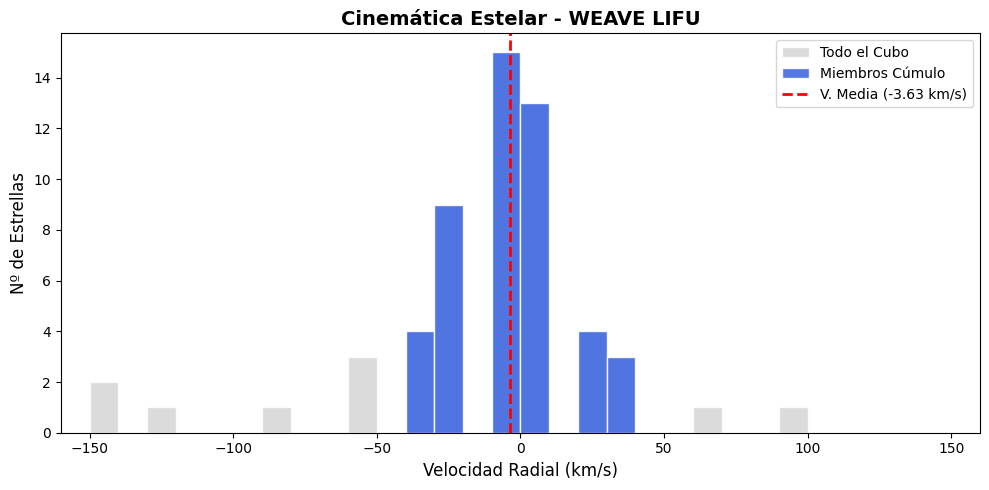

In [12]:
# ===============
#  HISTOGRAMA 
# ===============

plt.figure(figsize=(10, 5))

bins_hist = np.arange(-160, 170, 10)

plt.hist(df_valles['rv'], bins=bins_hist, color='lightgray', 
         edgecolor='white', label='Todo el Cubo', alpha=0.8)

plt.hist(df_final['rv'], bins=bins_hist, color='royalblue', 
         edgecolor='white', label='Miembros Cúmulo', alpha=0.9)

v_media = df_final['rv'].mean()
plt.axvline(v_media, color='red', linestyle='--', linewidth=2, 
            label=f'V. Media ({v_media:.2f} km/s)')

plt.title('Cinemática Estelar - WEAVE LIFU', fontsize=14, fontweight='bold')
plt.xlabel('Velocidad Radial (km/s)', fontsize=12)
plt.ylabel('Nº de Estrellas', fontsize=12)

plt.legend(loc='upper right', fontsize=10)
plt.xlim(-160, 160)
plt.tight_layout()
plt.show()

----------------------------------------
Confirmadas (Verdes): 45
Coladas (Rojas):      3
Perdidas (Azules):    8
----------------------------------------


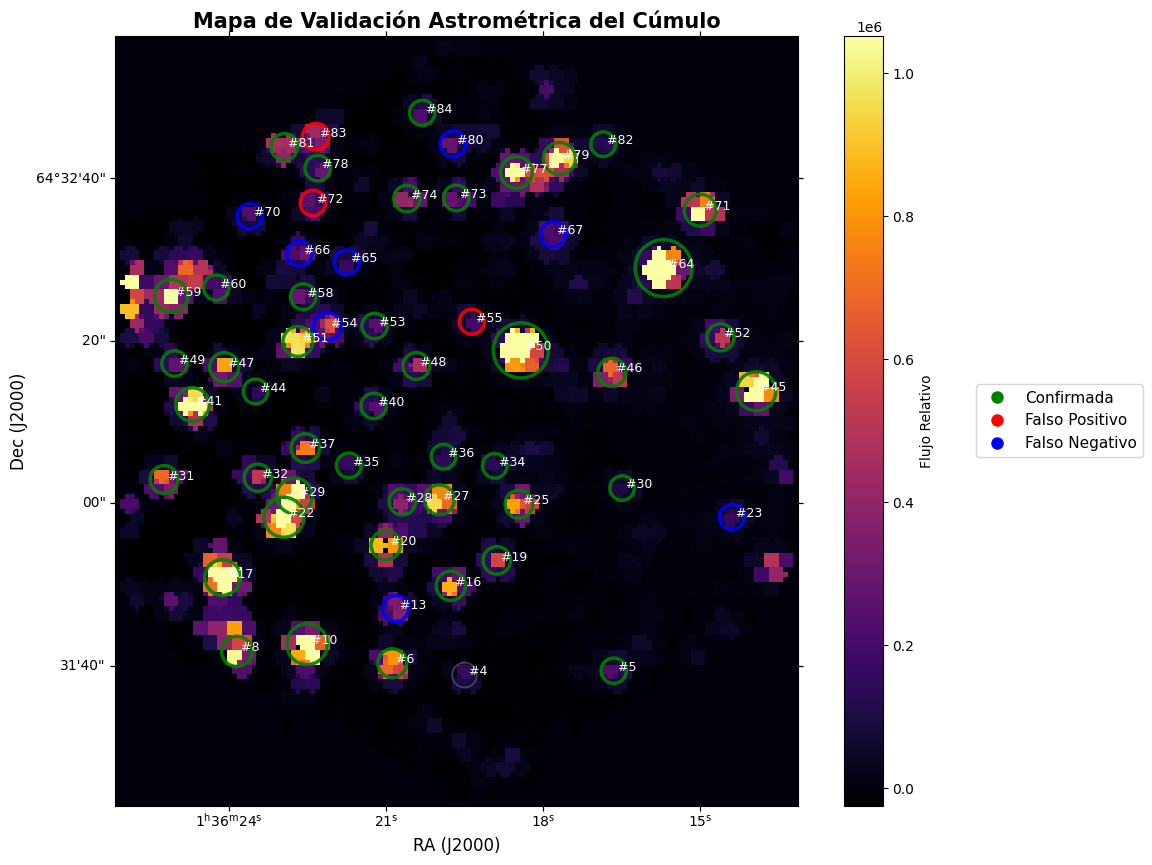

In [13]:

# =========================================================
#  VALIDACIÓN ASTROMÉTRICA CON GAIA DR3
# =========================================================
PMRA_REF = -0.673
PMDEC_REF = -0.072
TOLERANCIA = 0.5 

matriz = {'aciertos': 0, 'rechazos_ok': 0, 'falsos_positivos': 0, 'falsos_negativos': 0, 'sin_gaia': 0}
colores_gaia = {} 

for row in sources_final: 
    s_id = row['id']
    es_miembro_rv = s_id in miembros_ids # ¿La CCF dijo que era del cúmulo?
    
    info_gaia = sources_final[sources_final['id'] == s_id]
    
    if len(info_gaia) > 0 and not np.isnan(info_gaia['pmra'][0]):
        try:
            pmra = float(info_gaia['pmra'][0].value)
            pmdec = float(info_gaia['pmdec'][0].value)
        except AttributeError:
            pmra = float(info_gaia['pmra'][0])
            pmdec = float(info_gaia['pmdec'][0])
        
        es_miembro_gaia = (abs(pmra - PMRA_REF) <= TOLERANCIA) and (abs(pmdec - PMDEC_REF) <= TOLERANCIA)
        
        if es_miembro_rv and es_miembro_gaia:
            matriz['aciertos'] += 1
            color = 'green'
        elif not es_miembro_rv and not es_miembro_gaia:
            matriz['rechazos_ok'] += 1
            color = 'gray'
        elif es_miembro_rv and not es_miembro_gaia:
            matriz['falsos_positivos'] += 1
            color = 'red'
        elif not es_miembro_rv and es_miembro_gaia:
            matriz['falsos_negativos'] += 1
            color = 'blue'
            
        colores_gaia[s_id] = color
    else:
        matriz['sin_gaia'] += 1
        colores_gaia[s_id] = 'white' 

print("-" * 40)
print(f"Confirmadas (Verdes): {matriz['aciertos']}")
print(f"Coladas (Rojas):      {matriz['falsos_positivos']}")
print(f"Perdidas (Azules):    {matriz['falsos_negativos']}")
print("-" * 40)


# =========================================================
# 3. VISUALIZACIÓN ESPACIAL CON WCS Y COLORES
# =========================================================
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(1, 1, 1, projection=wcs)

im = ax.imshow(white, origin="lower", cmap="inferno", vmin=vmin_plot, vmax=vmax_plot)

for row in sources_final:
    s_id = row['id']
    color_circulo = colores_gaia.get(s_id, 'white')
    
    grosor = 2.5 if color_circulo in ['green', 'red', 'blue'] else 1.2
    alfa = 0.9 if color_circulo in ['green', 'red', 'blue'] else 0.5

    circ = SphericalCircle(
        (row['ra'] * u.deg, row['dec'] * u.deg), 
        row['radio_ext'] * u.arcsec,
        edgecolor=color_circulo, facecolor='none', lw=grosor, alpha=alfa,
        transform=ax.get_transform('world')
    )
    ax.add_patch(circ)
    
    ax.text(row['ra'], row['dec'], f" #{s_id}", color='white', 
            fontsize=9, transform=ax.get_transform('world'))

ax.coords['ra'].set_axislabel('RA (J2000)', fontsize=12)
ax.coords['dec'].set_axislabel('Dec (J2000)', fontsize=12)
ax.invert_xaxis()

plt.colorbar(im, ax=ax, label="Flujo Relativo")
plt.title("Mapa de Validación Astrométrica del Cúmulo", fontsize=15, fontweight='bold')

leyenda_mapa = [
    Line2D([0], [0], marker='o', color='w', label='Confirmada', markerfacecolor='green', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Falso Positivo', markerfacecolor='red', markersize=10),
    Line2D([0], [0], marker='o', color='w', label='Falso Negativo', markerfacecolor='blue', markersize=10), ]
ax.legend(handles=leyenda_mapa, loc='center left', bbox_to_anchor=(1.25, 0.5), fontsize=11)

plt.show()

In [14]:

df_miembros = df_valles[df_valles['id'].isin(miembros_ids)].copy()

datos_tabla = []

for index, row in df_miembros.iterrows():
    s_id = row['id']
    vr = row['rv']
    tipo_largo = row['tipo'] 
    
    tipo_corto = "Temprana" if "Temprana" in tipo_largo else "Tardía"
        
    ra = espectros_finales[s_id]['ra']
    dec = espectros_finales[s_id]['dec']
    snr = espectros_finales[s_id]['snr']
    
    datos_tabla.append({
        'ID': int(s_id),
        'RA (deg)': f"{ra:.6f}",
        'Dec (deg)': f"{dec:.6f}",
        'Vr [km/s]': f"{vr:.2f}",
        'SNR': f"{snr:.1f}",
        'Tipo': tipo_corto
    })

df_memoria = pd.DataFrame(datos_tabla)
df_memoria = df_memoria.sort_values(by='ID')

print(df_memoria.to_string(index=False, justify='center'))

 ID  RA (deg) Dec (deg) Vr [km/s]  SNR    Tipo  
  5 24.069379 64.527613     0.04   10.9 Temprana
  6 24.086987 64.527871    -0.01   43.1 Temprana
  8 24.099357 64.528274   -29.77   33.7 Temprana
 10 24.093764 64.528520    -0.04   81.0 Temprana
 16 24.082331 64.530515     0.05   28.4 Temprana
 17 24.100481 64.530800    30.77   80.3 Temprana
 19 24.078678 64.531386     0.02   20.4 Temprana
 20 24.087509 64.531902    28.01   39.6 Temprana
 22 24.095610 64.532860     0.04   74.5 Temprana
 25 24.076912 64.533307    -0.00   41.4 Temprana
 27 24.083245 64.533459     0.02   46.2 Temprana
 28 24.086199 64.533387    31.38   20.6 Temprana
 29 24.094763 64.533590     0.04   64.0 Temprana
 30 24.068711 64.533858   -28.03    5.2 Temprana
 31 24.105147 64.534150   -32.16   31.6 Temprana
 32 24.097691 64.534214   -29.26   20.1 Temprana
 34 24.078833 64.534622   -28.84    7.4 Temprana
 35 24.090441 64.534633   -27.67    8.7 Temprana
 36 24.082915 64.534934     0.01    7.7   Tardía
 37 24.093904 64.535